In [47]:
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
df = pd.read_csv("used_cars_data.csv")
print(df)

       S.No.                                               Name    Location  \
0          0                             Maruti Wagon R LXI CNG      Mumbai   
1          1                   Hyundai Creta 1.6 CRDi SX Option        Pune   
2          2                                       Honda Jazz V     Chennai   
3          3                                  Maruti Ertiga VDI     Chennai   
4          4                    Audi A4 New 2.0 TDI Multitronic  Coimbatore   
...      ...                                                ...         ...   
58019  58019                  Volkswagen Vento Diesel Trendline   Hyderabad   
58020  58020                             Volkswagen Polo GT TSI      Mumbai   
58021  58021                             Nissan Micra Diesel XV     Kolkata   
58022  58022                             Volkswagen Polo GT TSI        Pune   
58023  58023  Mercedes-Benz E-Class 2009-2013 E 220 CDI Avan...       Kochi   

       Year  Kilometers_Driven Fuel_Type Transmissi

In [49]:
df.isnull().sum()

S.No.                    0
Name                     0
Location                 0
Year                     0
Kilometers_Driven        0
Fuel_Type                0
Transmission             0
Owner Type               0
Mileage                 16
Engine                 368
Power                  368
Seats                  424
New_Price            49976
Price                 9872
dtype: int64

In [50]:
df.dropna(axis=1)

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner Type
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second
...,...,...,...,...,...,...,...,...
58019,58019,Volkswagen Vento Diesel Trendline,Hyderabad,2011,89411,Diesel,Manual,First
58020,58020,Volkswagen Polo GT TSI,Mumbai,2015,59000,Petrol,Automatic,First
58021,58021,Nissan Micra Diesel XV,Kolkata,2012,28000,Diesel,Manual,First
58022,58022,Volkswagen Polo GT TSI,Pune,2013,52262,Petrol,Automatic,Third


In [51]:
print(df.mean(numeric_only = True))
print(df.median(numeric_only = True))
print(df.std(numeric_only = True))
print(df.iloc[0])
      

S.No.                29011.500000
Year                  2013.365366
Kilometers_Driven    58699.063146
Seats                    5.279722
Price                    9.479468
dtype: float64
S.No.                29011.50
Year                  2014.00
Kilometers_Driven    53416.00
Seats                    5.00
Price                    5.64
dtype: float64
S.No.                16750.230347
Year                     3.254224
Kilometers_Driven    84422.627672
Seats                    0.811610
Price                   11.187104
dtype: float64
S.No.                                     0
Name                 Maruti Wagon R LXI CNG
Location                             Mumbai
Year                                   2010
Kilometers_Driven                     72000
Fuel_Type                               CNG
Transmission                         Manual
Owner Type                            First
Mileage                          26.6 km/kg
Engine                               998 CC
Power                    

In [56]:
print(df.select_dtypes(include=['number']).columns.tolist())
print(df.select_dtypes(include=['category','object']).columns.tolist())

['S.No.', 'Year', 'Kilometers_Driven', 'Seats', 'Price']
['Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner Type', 'Mileage', 'Engine', 'Power', 'New_Price']


In [59]:
df.to_csv("cleaned.csv")

In [61]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

In [63]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(outliers)


Empty DataFrame
Columns: [S.No., Name, Location, Year, Kilometers_Driven, Fuel_Type, Transmission, Owner Type, Mileage, Engine, Power, Seats, New_Price, Price]
Index: []
       S.No.                              Name   Location  Year  \
274      274               Maruti Zen VXI BSII     Mumbai  2002   
315      315                   Tata Sumo Delux  Hyderabad  2000   
364      364                     Maruti Zen LX    Kolkata  2003   
613      613         Mahindra Bolero ZLX BSIII    Kolkata  2000   
631      631         Hyundai Santro LS zipPlus    Chennai  2002   
...      ...                               ...        ...   ...   
57347  57347         Hyundai Santro LS zipPlus    Kolkata  2002   
57524  57524                     Maruti 800 DX     Jaipur  2000   
57646  57646               Toyota Qualis FS B3       Pune  2002   
57757  57757  Mercedes-Benz E-Class E240 V6 AT     Mumbai  2003   
57909  57909     Toyota Corolla Executive (HE)    Chennai  2003   

       Kilometers_Driven 

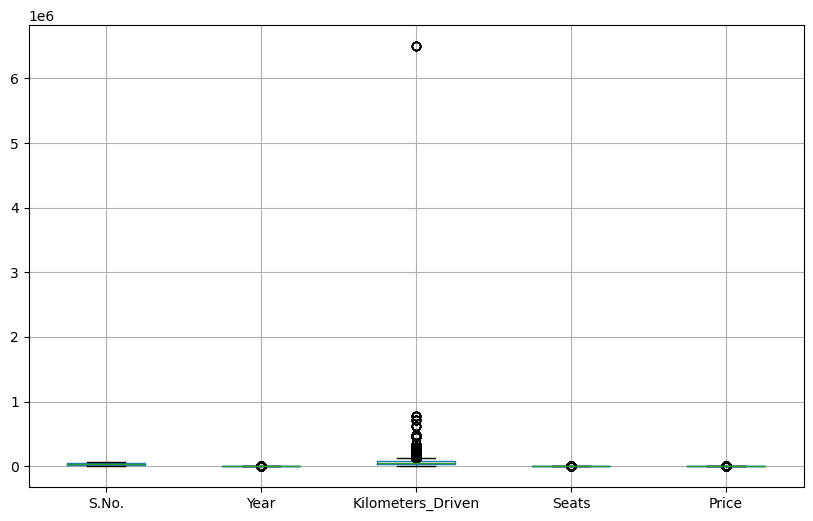

In [69]:
plt.figure(figsize = (10,6))
df.boxplot(column = numeric_cols)
plt.show()

In [71]:
df = df[(df[col] >= lower_bound) & (df[col] < upper_bound)]
print(df)

       S.No.                              Name    Location  Year  \
0          0            Maruti Wagon R LXI CNG      Mumbai  2010   
1          1  Hyundai Creta 1.6 CRDi SX Option        Pune  2015   
2          2                      Honda Jazz V     Chennai  2011   
3          3                 Maruti Ertiga VDI     Chennai  2012   
4          4   Audi A4 New 2.0 TDI Multitronic  Coimbatore  2013   
...      ...                               ...         ...   ...   
56785  56785                  Maruti Swift VDI       Delhi  2014   
56786  56786          Hyundai Xcent 1.1 CRDi S      Jaipur  2015   
56787  56787             Mahindra Xylo D4 BSIV      Jaipur  2012   
56788  56788                Maruti Wagon R VXI     Kolkata  2013   
56789  56789             Chevrolet Beat Diesel   Hyderabad  2011   

       Kilometers_Driven Fuel_Type Transmission Owner Type     Mileage  \
0                  72000       CNG       Manual      First  26.6 km/kg   
1                  41000    Diesel 

In [75]:
from scipy import stats

In [77]:
df_z_scores = df[numeric_cols].apply(stats.zscore)
outliers = (abs(df_z_scores) > 3)
print(outliers)

       S.No.   Year  Kilometers_Driven  Seats  Price
0      False  False              False  False  False
1      False  False              False  False  False
2      False  False              False  False  False
3      False  False              False  False  False
4      False  False              False  False  False
...      ...    ...                ...    ...    ...
56785  False  False              False  False  False
56786  False  False              False  False  False
56787  False  False              False  False  False
56788  False  False              False  False  False
56789  False  False              False  False  False

[42408 rows x 5 columns]


In [79]:
df = (abs(df_z_scores) < 3)
print(df)

       S.No.  Year  Kilometers_Driven  Seats  Price
0       True  True               True  False   True
1       True  True               True  False   True
2       True  True               True  False   True
3       True  True               True  False   True
4       True  True               True  False   True
...      ...   ...                ...    ...    ...
56785   True  True               True  False   True
56786   True  True               True  False   True
56787   True  True               True  False   True
56788   True  True               True  False   True
56789   True  True               True  False   True

[42408 rows x 5 columns]
